In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, log_loss
from statsmodels.stats.contingency_tables import mcnemar

In [3]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "requirements.txt").exists():
    if (PROJECT_ROOT.parent / "requirements.txt").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise FileNotFoundError("Wrong directory")
    
DATA_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

Project root: /Users/tolulopesoetan/Desktop/pl_prediction_model
Data directory: /Users/tolulopesoetan/Desktop/pl_prediction_model/data/processed
Artifacts directory: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts


In [4]:
# load saved artifacts

features_v2 = pd.read_csv(DATA_DIR / "features_v2.csv")
features_v2["Date"] = pd.to_datetime(features_v2["Date"])
features_v2["season"] = features_v2["season"].astype(str)

classical_results = pd.read_csv(ARTIFACTS_DIR / "classical_model_results.csv")
halftime_results = pd.read_csv(ARTIFACTS_DIR / "halftime_model_results.csv")
nlp_ablation_results = pd.read_csv(ARTIFACTS_DIR / "nlp_ablation_results.csv")
test_predictions = pd.read_csv(ARTIFACTS_DIR / "test_predictions.csv")
test_predictions["Date"] = pd.to_datetime(test_predictions["Date"])

print("features_v2:", features_v2.shape)
print("classical_results:", classical_results.shape)
print("halftime_results:", halftime_results.shape)
print("nlp_ablation_results:", nlp_ablation_results.shape)
print("test_predictions:", test_predictions.shape)

features_v2: (1504, 27)
classical_results: (7, 6)
halftime_results: (4, 6)
nlp_ablation_results: (3, 6)
test_predictions: (379, 28)


In [5]:
# helper functions

def multiclass_brier_score(y_true_labels, proba, class_order):
    """
    Compute the multiclass Brier score from true labels and predicted probabilities.
    """
    y_true_onehot = pd.get_dummies(pd.Categorical(y_true_labels, categories=class_order))
    y_true_onehot = y_true_onehot.reindex(columns=class_order, fill_value=0)
    return np.mean(np.sum((y_true_onehot.values - proba) ** 2, axis=1))


def extract_probability_matrix(df, prefix, class_order):
    """
    Build a probability matrix from exported probability columns for one model.
    """
    return np.column_stack([df[f"{prefix}_{cls}"].values for cls in class_order])


def compute_metrics(name, y_true, y_pred, proba, class_order):
    """
    Compute standard evaluation metrics for one model.
    """
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "log_loss": log_loss(y_true, proba, labels=class_order),
        "brier_score": multiclass_brier_score(y_true, proba, class_order),
    }


def top_class_probability(proba):
    """
    Return the top predicted probability for each row.
    """
    return np.max(proba, axis=1)

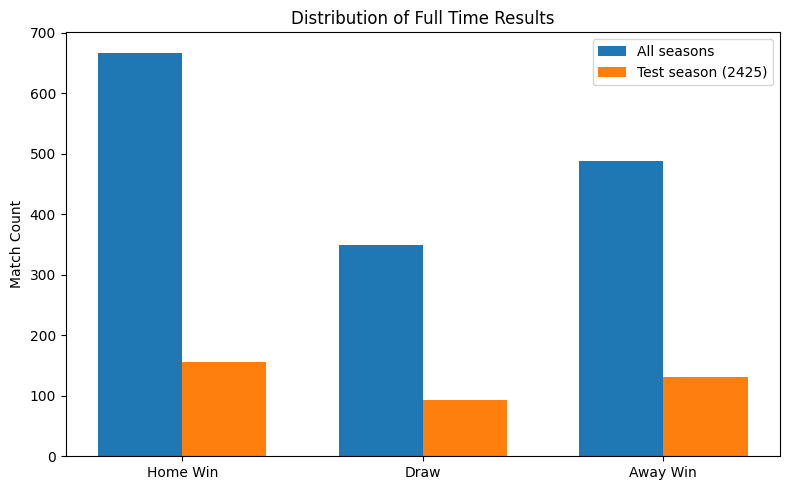

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/full_time_result_distribution.png


In [6]:
# distribution of full time results

ftr_counts_all = features_v2["FTR"].value_counts().reindex(["H", "D", "A"], fill_value=0)
ftr_counts_test = test_predictions["FTR"].value_counts().reindex(["H", "D", "A"], fill_value=0)

x = np.arange(len(ftr_counts_all.index))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, ftr_counts_all.values, width=width, label="All seasons")
plt.bar(x + width / 2, ftr_counts_test.values, width=width, label="Test season (2425)")
plt.xticks(x, ["Home Win", "Draw", "Away Win"])
plt.ylabel("Match Count")
plt.title("Distribution of Full Time Results")
plt.legend()
plt.tight_layout()

ftr_dist_path = ARTIFACTS_DIR / "full_time_result_distribution.png"
plt.savefig(ftr_dist_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {ftr_dist_path}")

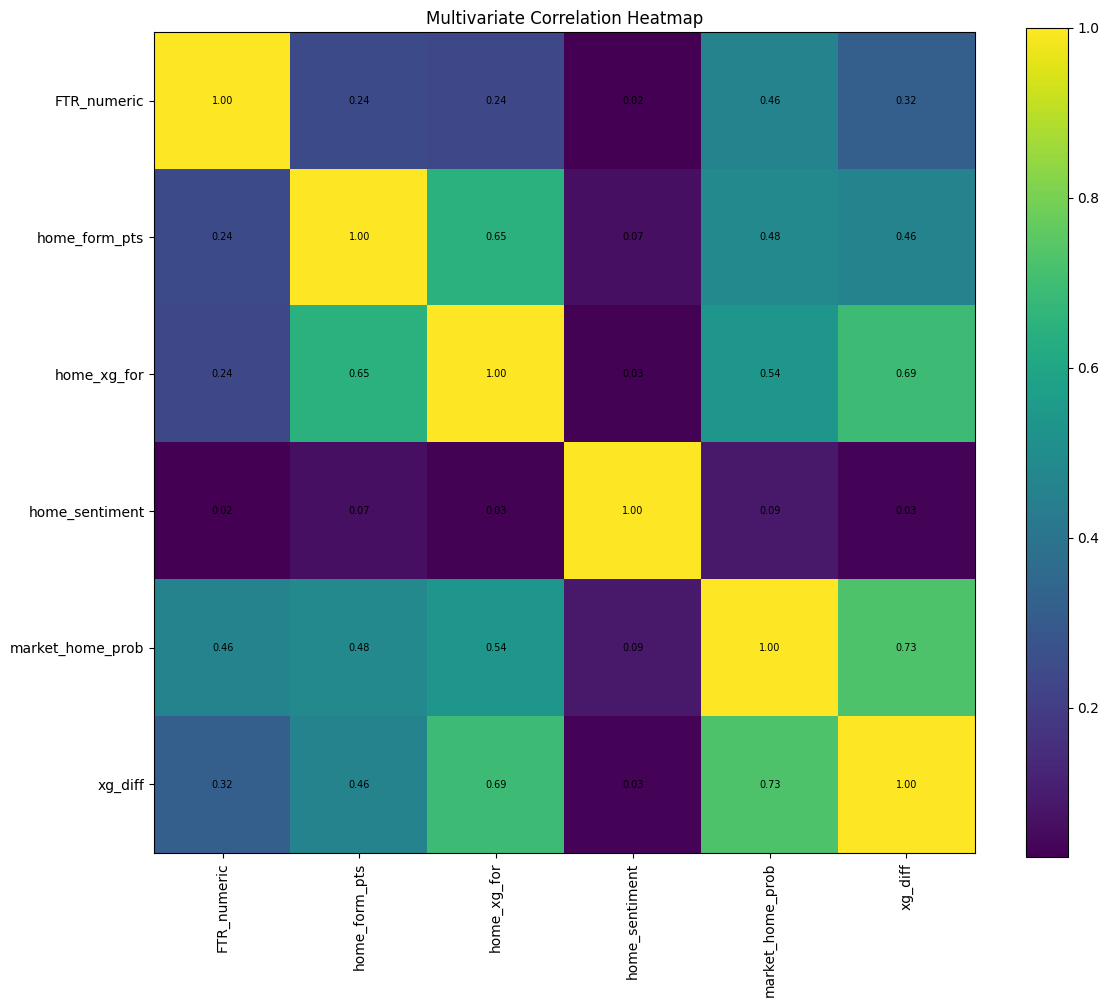

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/multivariate_correlation_heatmap.png


In [20]:
# multivariate correlation heatmap

corr_df = features_v2.copy()
corr_df["FTR_numeric"] = corr_df["FTR"].map({"H": 1, "D": 0, "A": -1})

heatmap_cols = [
    "FTR_numeric",
    "home_form_pts",
    "home_xg_for",
    "home_sentiment",
    "market_home_prob",
    "xg_diff"
]

corr_matrix = corr_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values)

ax.set_xticks(np.arange(len(heatmap_cols)))
ax.set_yticks(np.arange(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=90)
ax.set_yticklabels(heatmap_cols)

for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        ax.text(
            j,
            i,
            f"{corr_matrix.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

plt.colorbar(im)
plt.title("Multivariate Correlation Heatmap")
plt.tight_layout()

corr_path = ARTIFACTS_DIR / "multivariate_correlation_heatmap.png"
plt.savefig(corr_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {corr_path}")

In [7]:
# pre-match results tables

classical_results.round(4)

,model,cv_accuracy_mean,test_accuracy,weighted_f1,log_loss,brier_score
0,Market (Bet365),NaN,0.5383,0.4589,0.9724,0.5799
1,Random Forest,0.5644,0.5277,0.4523,0.9894,0.5901
2,KNN,0.5227,0.5251,0.4784,1.5686,0.6184
3,Gaussian Naive Bayes,0.5360,0.5198,0.4761,1.5843,0.7242
4,Logistic Regression,0.5102,0.5013,0.4977,0.9907,0.5942
5,Decision Tree,0.5031,0.5013,0.4661,2.5318,0.6276
6,SVM,0.4916,0.4908,0.4828,0.9996,0.5981


In [8]:
#NLP ablation results

nlp_ablation_results.round(4)

,model,cv_accuracy_mean,test_accuracy,weighted_f1,log_loss,brier_score
0,RF - pre-match + sentiment,0.5653,0.5383,0.4641,0.9939,0.5918
1,RF - pre-match,0.5644,0.5277,0.4523,0.9894,0.5901
2,LR - pre-match + sentiment,0.5147,0.4881,0.4896,0.9969,0.5985


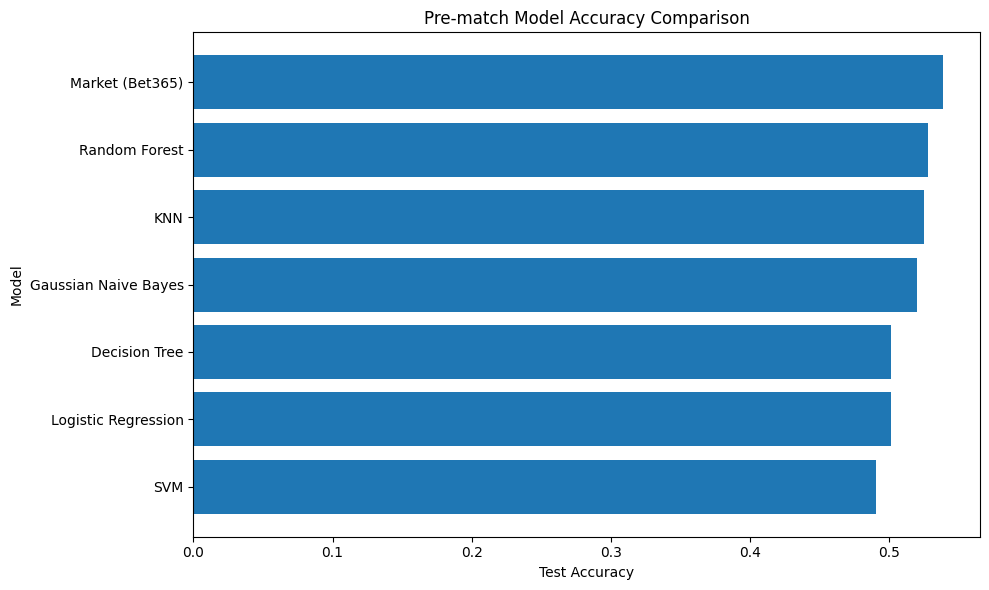

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/model_comparison.png


In [9]:
# plot pre-match comparison

plot_df = classical_results.sort_values("test_accuracy", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["model"], plot_df["test_accuracy"])
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Pre-match Model Accuracy Comparison")
plt.tight_layout()

pre_match_plot_path = ARTIFACTS_DIR / "model_comparison.png"
plt.savefig(pre_match_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {pre_match_plot_path}")

In [10]:
# half-time comparison table

halftime_results.round(4)

,model,cv_accuracy_mean,test_accuracy,weighted_f1,log_loss,brier_score
0,RF - half-time,0.6258,0.6095,0.5741,0.8837,0.5148
1,LR - half-time,0.5991,0.5805,0.5855,0.8591,0.5093
2,RF - pre-match,0.5644,0.5277,0.4523,0.9894,0.5901
3,LR - pre-match,0.5102,0.5013,0.4977,0.9907,0.5942


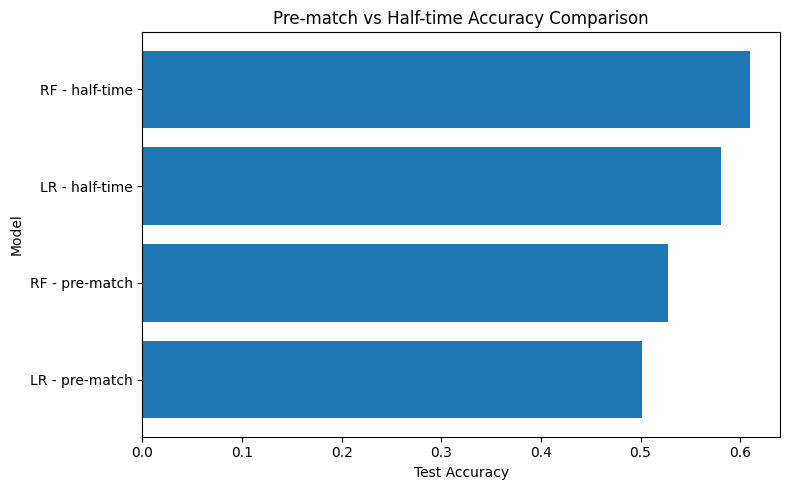

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/four_way_comparison.png


In [11]:
# plot pre-match vs half-time comparison

plot_ht_df = halftime_results.sort_values("test_accuracy", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_ht_df["model"], plot_ht_df["test_accuracy"])
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Pre-match vs Half-time Accuracy Comparison")
plt.tight_layout()

half_time_plot_path = ARTIFACTS_DIR / "four_way_comparison.png"
plt.savefig(half_time_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {half_time_plot_path}")

In [21]:
# build final evaluation table

class_order = ["H", "D", "A"]
y_true = test_predictions["FTR"].values

market_proba = np.column_stack(
    [
        test_predictions["market_home_prob"].values,
        test_predictions["market_draw_prob"].values,
        test_predictions["market_away_prob"].values,
    ]
)
market_pred = test_predictions["market_prediction"].values

lr_pre_proba = extract_probability_matrix(test_predictions, "lr_pre_prob", class_order)
lr_ht_proba = extract_probability_matrix(test_predictions, "lr_ht_prob", class_order)
rf_pre_proba = extract_probability_matrix(test_predictions, "rf_pre_prob", class_order)
rf_ht_proba = extract_probability_matrix(test_predictions, "rf_ht_prob", class_order)
rf_nlp_proba = extract_probability_matrix(test_predictions, "rf_nlp_prob", class_order)

final_metrics = [
    compute_metrics("Market", y_true, market_pred, market_proba, class_order),
    compute_metrics("LR - pre-match", y_true, test_predictions["lr_pre_pred"].values, lr_pre_proba, class_order),
    compute_metrics("LR - half-time", y_true, test_predictions["lr_ht_pred"].values, lr_ht_proba, class_order),
    compute_metrics("RF - pre-match", y_true, test_predictions["rf_pre_pred"].values, rf_pre_proba, class_order),
    compute_metrics("RF - pre-match + sentiment", y_true, test_predictions["rf_nlp_pred"].values, rf_nlp_proba, class_order),
    compute_metrics("RF - half-time", y_true, test_predictions["rf_ht_pred"].values, rf_ht_proba, class_order),
]

eval_df = pd.DataFrame(final_metrics).reset_index(drop=True)
eval_df.round(4)

,model,accuracy,weighted_f1,log_loss,brier_score
0,Market,0.5383,0.4589,1.4180,0.5799
1,LR - pre-match,0.5013,0.4977,1.4869,0.5942
2,LR - half-time,0.5805,0.5855,2.4472,0.5093
3,RF - pre-match,0.5277,0.4523,1.4218,0.5901
4,RF - pre-match + sentiment,0.5383,0.4641,1.4371,0.5918
5,RF - half-time,0.6095,0.5741,2.0348,0.5148


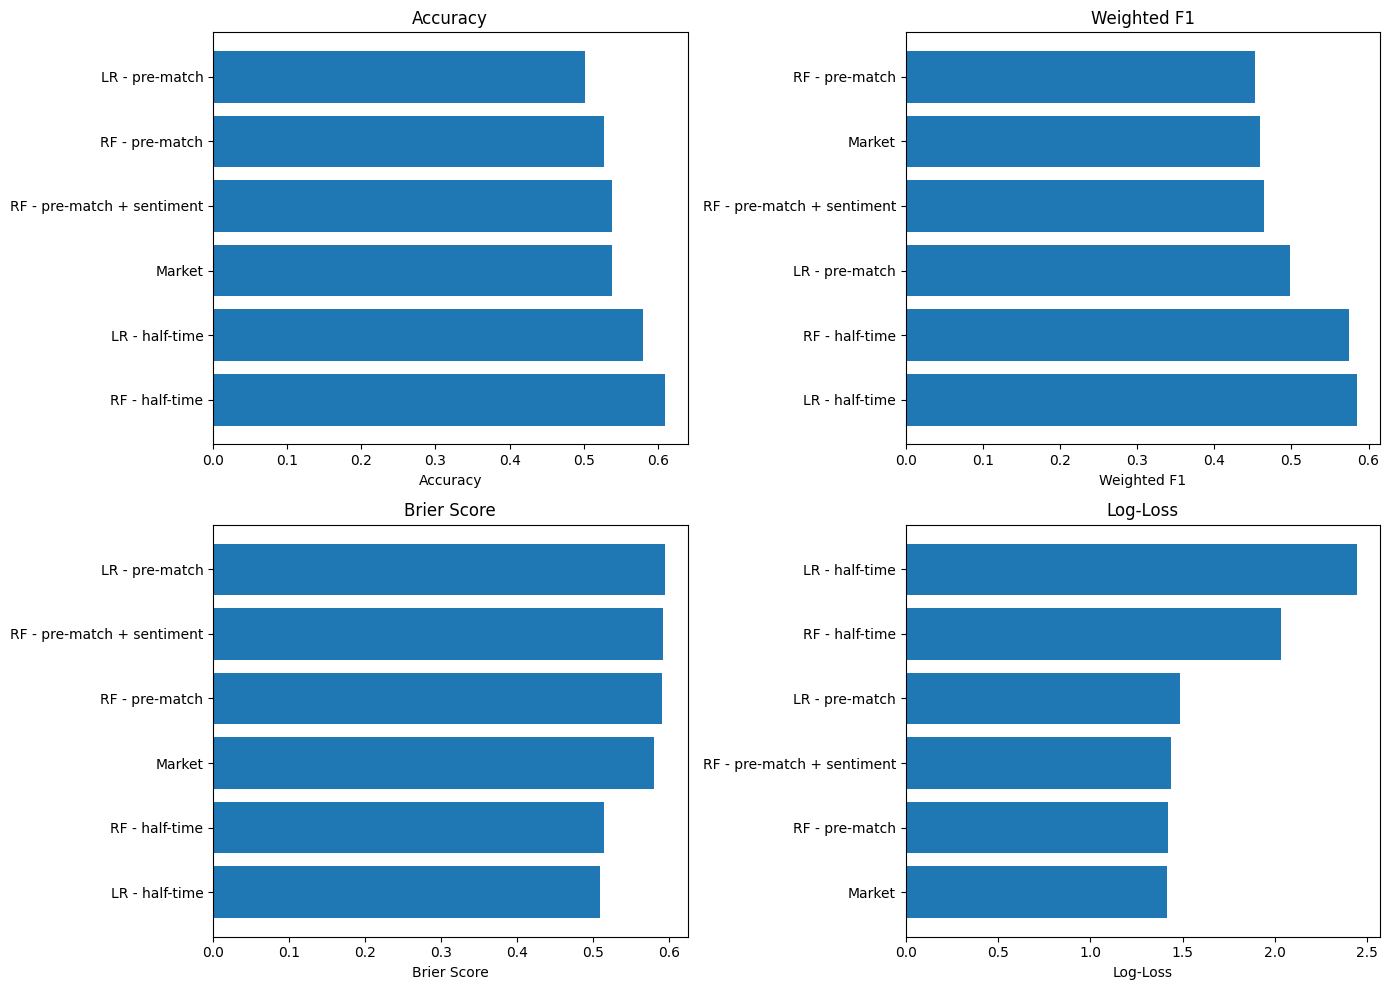

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/full_model_comparison_metrics.png


In [23]:
# Full model comparison across Accuracy, Weighted F1, Brier Score, and Log-Loss

plot_eval_df = eval_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_specs = [
    ("accuracy", "Accuracy", False),
    ("weighted_f1", "Weighted F1", False),
    ("brier_score", "Brier Score", True),
    ("log_loss", "Log-Loss", True),
]

for ax, (col, title, ascending) in zip(axes.flatten(), metric_specs):
    temp = plot_eval_df.sort_values(col, ascending=ascending)
    ax.barh(temp["model"], temp[col])
    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()

full_comp_path = ARTIFACTS_DIR / "full_model_comparison_metrics.png"
plt.savefig(full_comp_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {full_comp_path}")

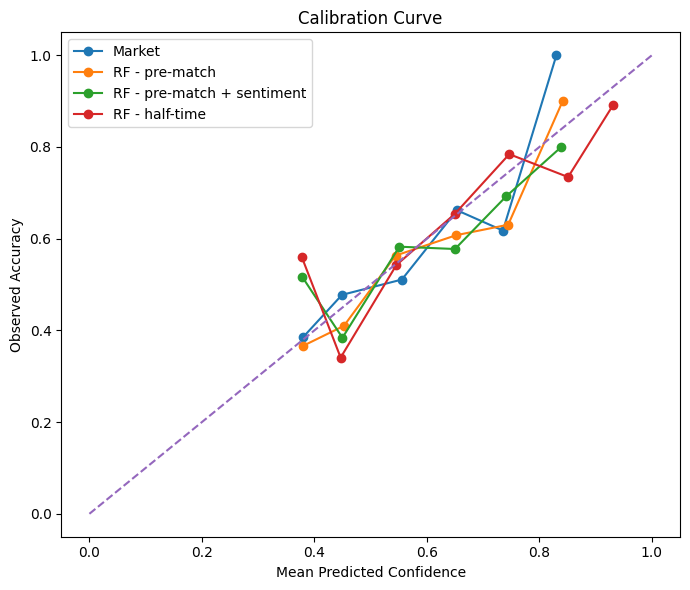

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/calibration.png


In [13]:
# calibration curves

plt.figure(figsize=(7, 6))

models_for_calibration = {
    "Market": market_proba,
    "RF - pre-match": rf_pre_proba,
    "RF - pre-match + sentiment": rf_nlp_proba,
    "RF - half-time": rf_ht_proba,
}

for label, proba in models_for_calibration.items():
    conf = top_class_probability(proba)
    pred = np.array(class_order)[np.argmax(proba, axis=1)]
    correct = (pred == y_true).astype(int)

    frac_pos, mean_pred = calibration_curve(correct, conf, n_bins=10, strategy="uniform")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Observed Accuracy")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()

calibration_path = ARTIFACTS_DIR / "calibration.png"
plt.savefig(calibration_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {calibration_path}")

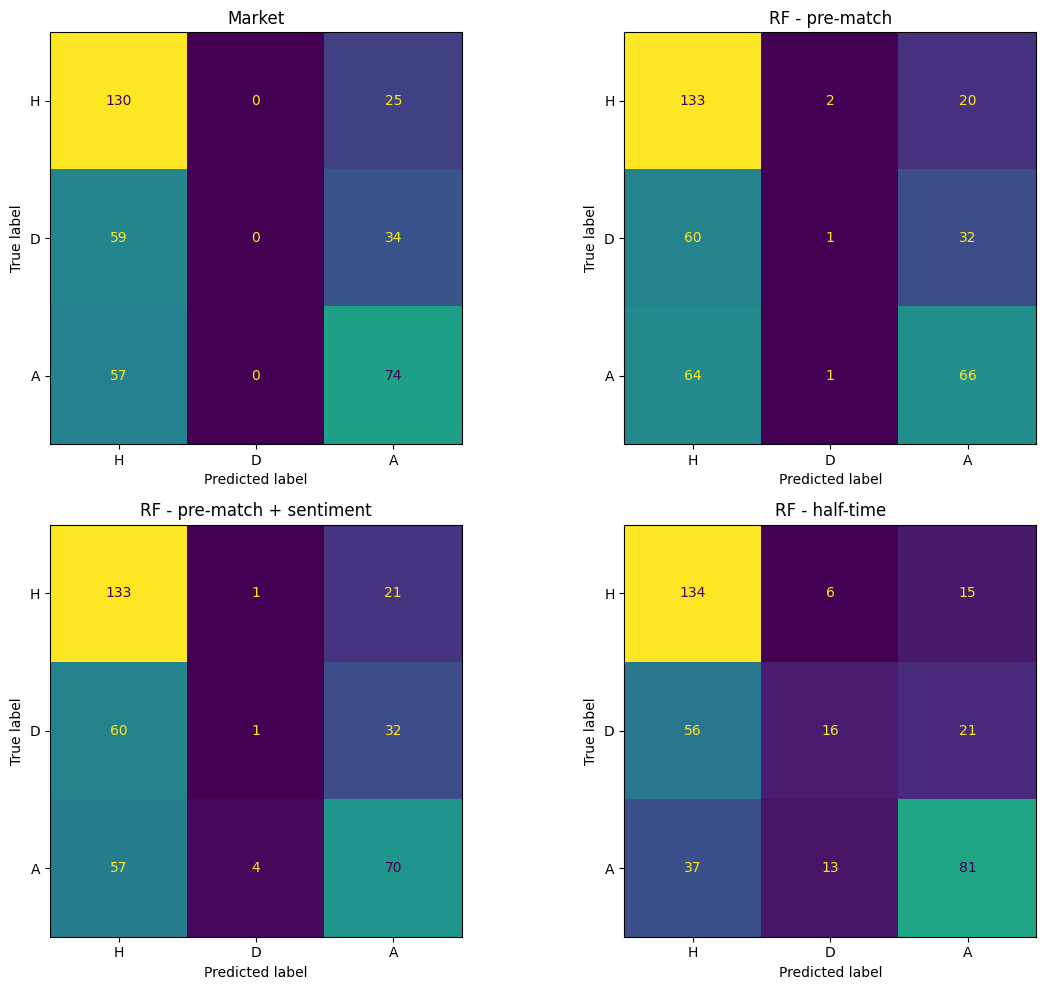

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/confusion_matrices.png


In [14]:
# confusion matrices

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

confusion_items = [
    ("Market", market_pred),
    ("RF - pre-match", test_predictions["rf_pre_pred"].values),
    ("RF - pre-match + sentiment", test_predictions["rf_nlp_pred"].values),
    ("RF - half-time", test_predictions["rf_ht_pred"].values),
]

for ax, (title, preds) in zip(axes.flatten(), confusion_items):
    cm = confusion_matrix(y_true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()

cm_path = ARTIFACTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {cm_path}")

In [15]:
# subgroup analysis

top_6 = {"Arsenal", "Chelsea", "Liverpool", "Man City", "Man United", "Tottenham"}

subgroup_df = test_predictions.copy()
subgroup_df["top6_involved"] = subgroup_df["HomeTeam"].isin(top_6) | subgroup_df["AwayTeam"].isin(top_6)
subgroup_df["high_form_gap"] = (
    np.abs(
        features_v2.loc[features_v2["season"] == "2425", "home_form_pts"].reset_index(drop=True)
        - features_v2.loc[features_v2["season"] == "2425", "away_form_pts"].reset_index(drop=True)
    ) >= 0.75
)
subgroup_df["contested_match"] = np.abs(
    subgroup_df["market_home_prob"] - subgroup_df["market_away_prob"]
) <= 0.10
subgroup_df["heavy_favourite"] = np.maximum(
    subgroup_df["market_home_prob"], subgroup_df["market_away_prob"]
) >= 0.60

groups = {
    "All matches": np.ones(len(subgroup_df), dtype=bool),
    "Top-6 involved": subgroup_df["top6_involved"].values,
    "High form gap": subgroup_df["high_form_gap"].values,
    "Contested match": subgroup_df["contested_match"].values,
    "Heavy favourite": subgroup_df["heavy_favourite"].values,
}

subgroup_rows = []

for group_name, mask in groups.items():
    if mask.sum() == 0:
        continue

    subgroup_rows.append(
        {
            "group": group_name,
            "n_matches": int(mask.sum()),
            "market_accuracy": accuracy_score(y_true[mask], market_pred[mask]),
            "rf_pre_accuracy": accuracy_score(y_true[mask], test_predictions.loc[mask, "rf_pre_pred"]),
            "rf_nlp_accuracy": accuracy_score(y_true[mask], test_predictions.loc[mask, "rf_nlp_pred"]),
            "rf_ht_accuracy": accuracy_score(y_true[mask], test_predictions.loc[mask, "rf_ht_pred"]),
        }
    )

subgroup_results = pd.DataFrame(subgroup_rows)
subgroup_results.round(4)

,group,n_matches,market_accuracy,rf_pre_accuracy,rf_nlp_accuracy,rf_ht_accuracy
0,All matches,379,0.5383,0.5277,0.5383,0.6095
1,Top-6 involved,197,0.5838,0.5685,0.5787,0.6244
2,High form gap,188,0.5798,0.5638,0.5745,0.6277
3,Contested match,83,0.3976,0.3976,0.4096,0.6145
4,Heavy favourite,119,0.6891,0.6891,0.6891,0.7143


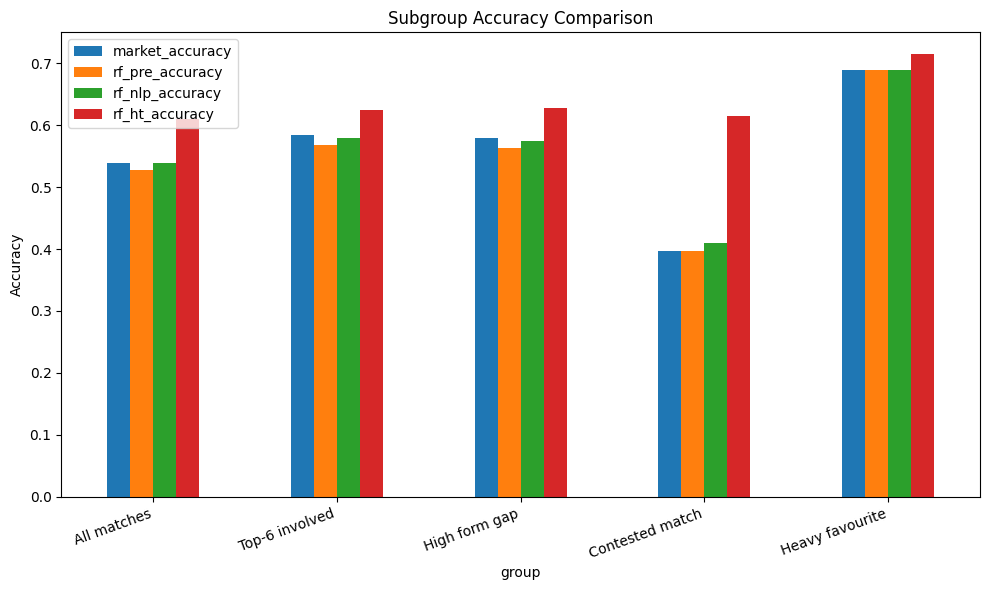

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/subgroup_analysis.png


In [16]:
plot_sub = subgroup_results.set_index("group")[["market_accuracy", "rf_pre_accuracy", "rf_nlp_accuracy", "rf_ht_accuracy"]]

plot_sub.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Accuracy")
plt.title("Subgroup Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

subgroup_path = ARTIFACTS_DIR / "subgroup_analysis.png"
plt.savefig(subgroup_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {subgroup_path}")

In [24]:
# Performance by match type: NLP vs Market

top_6 = {"Arsenal", "Chelsea", "Liverpool", "Man City", "Man United", "Tottenham"}

match_type_df = test_predictions.copy()
match_type_df["top6_involved"] = match_type_df["HomeTeam"].isin(top_6) | match_type_df["AwayTeam"].isin(top_6)
match_type_df["contested_match"] = np.abs(
    match_type_df["market_home_prob"] - match_type_df["market_away_prob"]
) <= 0.10
match_type_df["heavy_favourite"] = np.maximum(
    match_type_df["market_home_prob"], match_type_df["market_away_prob"]
) >= 0.60

features_2425 = features_v2.loc[features_v2["season"] == "2425"].reset_index(drop=True)
match_type_df["high_form_gap"] = np.abs(
    features_2425["home_form_pts"] - features_2425["away_form_pts"]
) >= 0.75

match_type_groups = {
    "All matches": np.ones(len(match_type_df), dtype=bool),
    "Top-6 involved": match_type_df["top6_involved"].values,
    "Contested match": match_type_df["contested_match"].values,
    "Heavy favourite": match_type_df["heavy_favourite"].values,
    "High form gap": match_type_df["high_form_gap"].values,
}

match_type_rows = []

for group_name, mask in match_type_groups.items():
    if mask.sum() == 0:
        continue

    match_type_rows.append(
        {
            "match_type": group_name,
            "n_matches": int(mask.sum()),
            "market_accuracy": accuracy_score(
                y_true[mask], match_type_df.loc[mask, "market_prediction"]
            ),
            "rf_nlp_accuracy": accuracy_score(
                y_true[mask], match_type_df.loc[mask, "rf_nlp_pred"]
            ),
        }
    )

match_type_results = pd.DataFrame(match_type_rows)
match_type_results.round(4)

,match_type,n_matches,market_accuracy,rf_nlp_accuracy
0,All matches,379,0.5383,0.5383
1,Top-6 involved,197,0.5838,0.5787
2,Contested match,83,0.3976,0.4096
3,Heavy favourite,119,0.6891,0.6891
4,High form gap,188,0.5798,0.5745


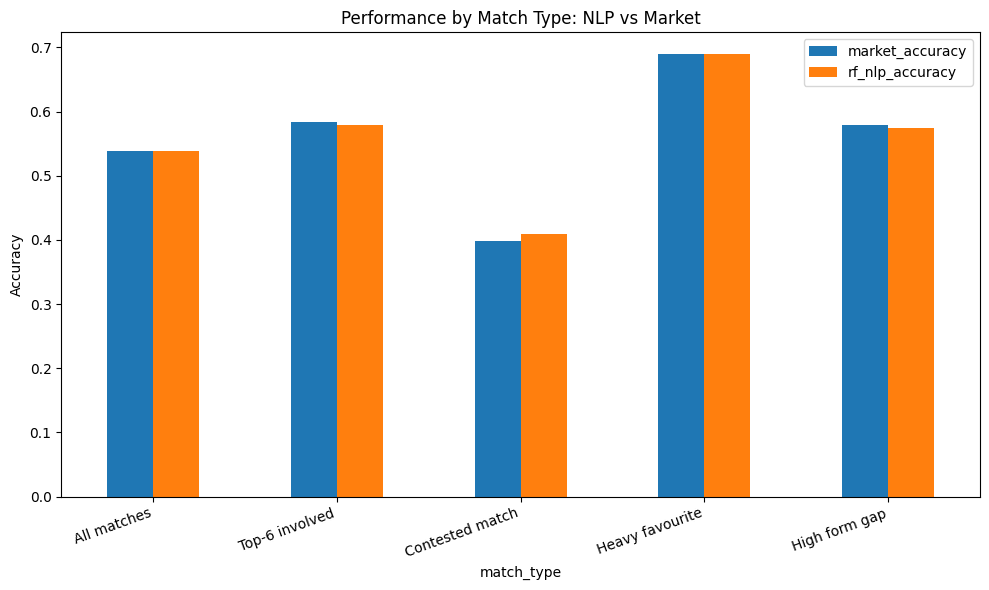

Saved chart to: /Users/tolulopesoetan/Desktop/pl_prediction_model/artifacts/nlp_vs_market_match_type.png


In [25]:
plot_mt = match_type_results.set_index("match_type")[["market_accuracy", "rf_nlp_accuracy"]]

plot_mt.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Accuracy")
plt.title("Performance by Match Type: NLP vs Market")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

match_type_path = ARTIFACTS_DIR / "nlp_vs_market_match_type.png"
plt.savefig(match_type_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {match_type_path}")

In [17]:
# McNemar tests

def mcnemar_table(y_true, pred_a, pred_b):
    """
    Build the 2x2 contingency table needed for McNemar's test.
    """
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    n00 = np.sum((~a_correct) & (~b_correct))
    n01 = np.sum((~a_correct) & (b_correct))
    n10 = np.sum((a_correct) & (~b_correct))
    n11 = np.sum((a_correct) & (b_correct))

    return np.array([[n11, n10], [n01, n00]])


comparisons = {
    "RF half-time vs Market": (
        test_predictions["rf_ht_pred"].values,
        market_pred,
    ),
    "RF half-time vs RF + sentiment": (
        test_predictions["rf_ht_pred"].values,
        test_predictions["rf_nlp_pred"].values,
    ),
    "RF + sentiment vs RF pre-match": (
        test_predictions["rf_nlp_pred"].values,
        test_predictions["rf_pre_pred"].values,
    ),
    "RF pre-match vs Market": (
        test_predictions["rf_pre_pred"].values,
        market_pred,
    ),
}

mcnemar_rows = []

for name, (pred_a, pred_b) in comparisons.items():
    table = mcnemar_table(y_true, pred_a, pred_b)
    result = mcnemar(table, exact=False, correction=True)

    mcnemar_rows.append(
        {
            "comparison": name,
            "statistic": result.statistic,
            "p_value": result.pvalue,
        }
    )

mcnemar_results = pd.DataFrame(mcnemar_rows)
mcnemar_results

,comparison,statistic,p_value
0,RF half-time vs Market,7.952941,0.004801
1,RF half-time vs RF + sentiment,7.952941,0.004801
2,RF + sentiment vs RF pre-match,1.125000,0.288844
3,RF pre-match vs Market,0.500000,0.479500


In [18]:
# final observations

eval_df.round(4)

,model,accuracy,weighted_f1,log_loss,brier_score
0,RF - half-time,0.6095,0.5741,2.0348,0.5148
1,LR - half-time,0.5805,0.5855,2.4472,0.5093
2,Market,0.5383,0.4589,1.4180,0.5799
3,RF - pre-match + sentiment,0.5383,0.4641,1.4371,0.5918
4,RF - pre-match,0.5277,0.4523,1.4218,0.5901
5,LR - pre-match,0.5013,0.4977,1.4869,0.5942
